In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Synthetic.csv')

In [3]:
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [4]:
df.drop(columns = "Unnamed: 0", inplace = True)

In [5]:
df.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


In [6]:
# Separating x and y
x = df.iloc[:,0].values
y = df.iloc[:,1].values

In [7]:
x.shape, y.shape

((50,), (50,))

In [8]:
class GradientDescent:
    def __init__(self, X, Y, lr, ep, tol):
        self.X = X
        self.Y = Y
        self.learningRate = lr
        self.epochs = ep
        self.tolerance = tol

    def standardizationAndReshape(self):
        self.X = (self.X - np.mean(self.X))/np.std(self.X)
        self.X = self.X.reshape(1, -1)
        self.Y = self.Y.reshape(-1, 1)

    def initializeModelParams(self):
        self.theta_0 = np.array(np.random.randn()).reshape(1,1)
        self.theta_1 = np.array(np.random.randn()).reshape(1,1)
        return (f"theta_0 = {self.theta_0}, theta_1 = {self.theta_1}")

    def batchGD(self):
        epoch = 1
        loss = 1
        self.losses = []
        noOfFeatures, m = self.X.shape
        bgd_theta_0 = self.theta_0
        bgd_theta_1 = self.theta_1

        while epoch <= self.epochs and loss > self.tolerance :
            # Forward pass
            y_hat = bgd_theta_1 * self.X + bgd_theta_0

            # Loss calculation
            loss = 1/2 * np.mean((y_hat.T - self.Y)**2)

            # derivative calculation
            d_bgd_theta_1 = 1/m * np.dot(self.X, (y_hat.T - self.Y))
            d_bgd_theta_0 = 1/m * np.sum(y_hat.T - self.Y)

            # Update parameters
            bgd_theta_1 = bgd_theta_1 - self.learningRate * d_bgd_theta_1
            bgd_theta_0 = bgd_theta_0 - self.learningRate * d_bgd_theta_0

            self.losses.append(loss)

            epoch += 1

        plt.plot(self.losses)
        plt.title("Batch Gradient Descent")
        plt.xlabel("Number of epochs")
        plt.ylabel("Loss (MSE)")
       

    def SGD(self):
        epoch = 1
        loss = 1
        self.sgd_losses = []
        sgd_theta_0 = self.theta_0
        sgd_theta_1 = self.theta_1

         
        m = self.X.shape[1]

        while epoch <= self.epochs:
            indices = []
            per_epoch_losses_sgd = []
            
            while len(indices) < m:
                indice = np.random.randint(0,m)

                if indice in indices:
                    continue
                y_hat = sgd_theta_1 * self.X[:, indice].reshape(1, 1) + sgd_theta_0

                loss = (1/2) * (y_hat - self.Y[indice, :].reshape(1, 1))**2

                d_sgd_theta_1 = self.X[:, indice].reshape(1, 1) * (y_hat - self.Y[indice, :].reshape(1, 1))
                d_sgd_theta_0 = y_hat - self.Y[indice, :].reshape(1, 1)
                
                # Update parameters
                sgd_theta_1 = sgd_theta_1 - self.learningRate * d_sgd_theta_1
                sgd_theta_0 = sgd_theta_0 - self.learningRate * d_sgd_theta_0
                
                per_epoch_losses_sgd.append(loss.item())

                indices.append(indice)

            self.sgd_losses.append(np.mean(per_epoch_losses_sgd))
            epoch += 1
            
        plt.plot(self.sgd_losses)
        plt.title("Stochastic Gradient Descent")
        plt.xlabel("Number of epochs")
        plt.ylabel("Loss (MSE)")

    def miniBatchGD(self, batch_size):
        epoch = 1
        loss = 1
        self.mbgd_losses = []
        mbgd_theta_0 = self.theta_0
        mbgd_theta_1 = self.theta_1
        
                 
        m = self.X.shape[1]
        
        while epoch <= self.epochs:
            shuffled_indices = np.random.permutation(m)
            per_epoch_losses_mbgd = []
                    
            for start in range(0, m, batch_size):
                batch_indices = shuffled_indices[start: start + batch_size]
                b = len(batch_indices)

                XBatch = self.X[:, batch_indices]
                YBatch = self.Y[batch_indices,]
        
                y_hat = mbgd_theta_1 * XBatch + mbgd_theta_0
        
                loss = 1/2 * np.mean((y_hat.T - YBatch)**2)
        
                d_mbgd_theta_1 = (1/b) * np.dot(XBatch, (y_hat.T - YBatch))
                d_mbgd_theta_0 = (1/b) * np.sum(y_hat.T - YBatch)
                        
                # Update parameters
                mbgd_theta_1 = mbgd_theta_1 - self.learningRate * d_mbgd_theta_1
                mbgd_theta_0 = mbgd_theta_0 - self.learningRate * d_mbgd_theta_0

                per_epoch_losses_mbgd.append(loss)
                        

            self.mbgd_losses.append(np.mean(per_epoch_losses_mbgd))

            epoch += 1

        plt.plot(self.mbgd_losses)
        plt.title("Mini Batch Gradient Descent")
        plt.xlabel("Number of epochs")
        plt.ylabel("Loss (MSE)")

In [9]:
gd = GradientDescent(x, y, 0.0001, 10000, 0.001)

In [10]:
gd.standardizationAndReshape()

In [11]:
gd.initializeModelParams()

'theta_0 = [[0.98659643]], theta_1 = [[0.12968814]]'

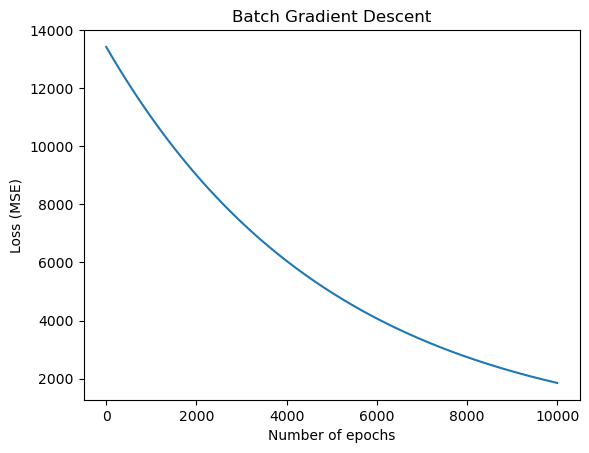

In [12]:
gd.batchGD()

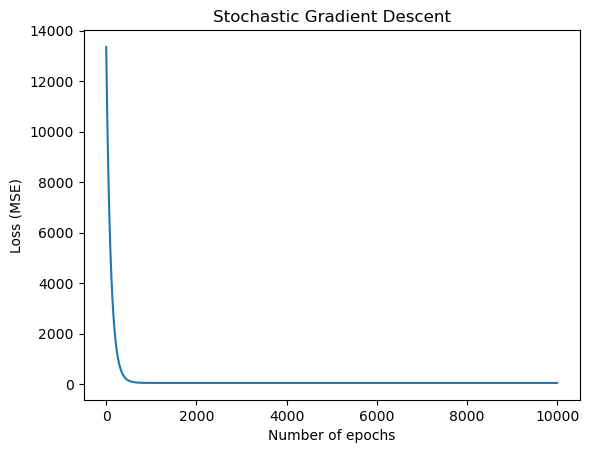

In [13]:
gd.SGD()

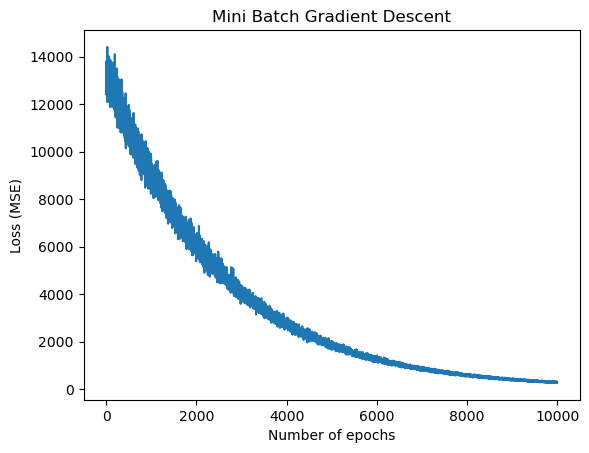

In [15]:
gd.miniBatchGD(32)